# Interface to Gadget simulations

It is possible to read gadget files (both snapshots and subfind catalogs) extracting the necessary information. The ```cluster``` class contains methods to produce mass maps projecting selected particles along arbitrary lines of sight:

Particle type, number: 0 4307587
Particle type, number: 0 4307587
Particle type, number: 1 5755627
Particle type, number: 4 1346754


Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

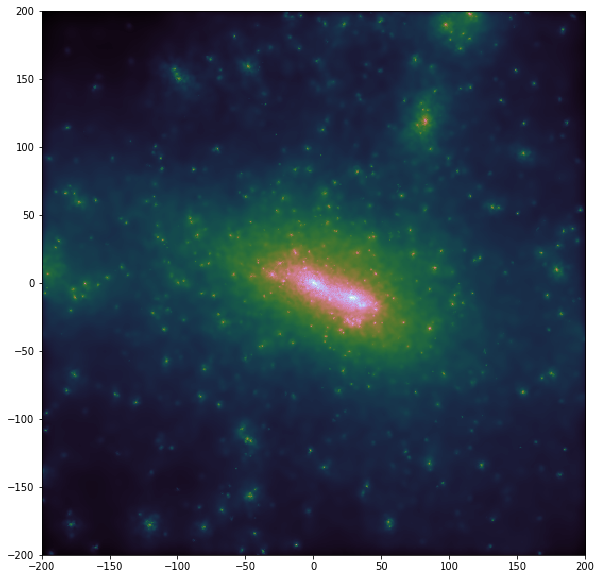

In [125]:
from pyLensLib.cluster import cluster
from pyLensLib.subfind import subfind
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

cluster_file = "snap_058"

snapshot = '/Users/massimo/projects/ggsl/testing_codes/massmaps_python/BH_2015/snap_058'
subfind_file = "/Users/massimo/stiva/Dianoga/new_elena/Subfind_AGN/D1/sub_058.0"
sf=subfind(subfind_file)
xc,yc,zc=sf.gpos[0]
cl = cluster(snapshot=snapshot,parttype=[0],xc=xc,yc=yc,zc=zc)

npix=512
fov=400.0
fov_mpc=fov * cl.co.angular_diameter_distance(cl.zl).value*np.pi/180./3600.
parttype = [0,1,4]
img = np.zeros((npix,npix))
for itype in parttype:
    cl=cluster(snapshot=snapshot,parttype=[itype],xc=xc,yc=yc,zc=zc)
    this_img = cl.massMapSPH(nb=20,pX=90.,pY=90,npix=npix,xmin=-fov_mpc/2.0,xmax=fov_mpc/2.0,ymin=-fov_mpc/2.0,ymax=fov_mpc/2.0,zmin=-10.0,zmax=10.0)
    img = img.copy() + this_img
    if itype == 0:
        gas_map=this_img.copy()
    if itype == 1:
        dm_map=this_img.copy()
    if itype == 4:
        star_map=this_img.copy()
fig,ax = plt.subplots(1,1,figsize=(10,10))
ax.imshow(np.sqrt(img),origin='low',cmap="cubehelix",extent=[-fov/2,fov/2,-fov/2.,fov/2.])
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

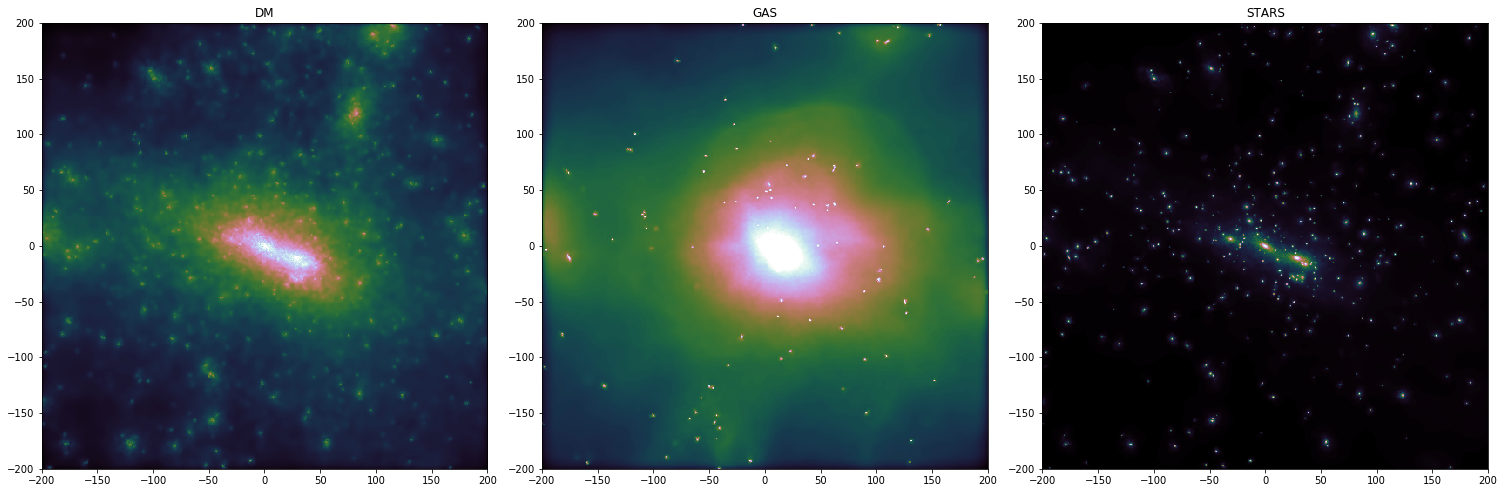

In [73]:
fig,ax = plt.subplots(1,3,figsize=(21,7))
ax[0].imshow(np.sqrt(dm_map),origin='low',extent=[-fov/2,fov/2,-fov/2.,fov/2.],vmax=np.max(np.sqrt(dm_map))*0.9,cmap="cubehelix")
ax[0].set_title('DM')
ax[1].imshow(np.sqrt(gas_map),origin='low',extent=[-fov/2,fov/2,-fov/2.,fov/2.],vmax=np.max(np.sqrt(gas_map))*0.5,cmap="cubehelix")
ax[1].set_title('GAS')
ax[2].imshow(np.sqrt(star_map),origin='low',extent=[-fov/2,fov/2,-fov/2.,fov/2.],vmax=np.max(np.sqrt(star_map))*0.8,cmap="cubehelix")
ax[2].set_title('STARS')
plt.tight_layout()
plt.show()

# Radial profiles

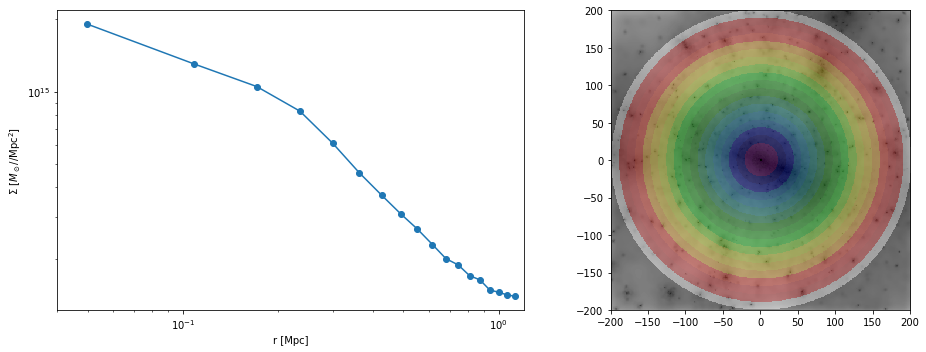

In [127]:
from pyLensLib.maputils import map_obj
%matplotlib inline

mpo = map_obj(img)

px=fov/(npix-1)
rbin, rb, radial_mean = mpo.radial_profile(auto_center=True,nbins=20,rmin=2,rmax=256,logspace=False)
DL=cl.co.angular_diameter_distance(cl.zl)
conv=(np.pi/180.0/3600.0*DL.value)
r=rb*px*conv
p=radial_mean/px/px/conv/conv

fig,ax=plt.subplots(1,2,figsize=(14,5))
ax[0].plot(r,p,'-o')
#plt.axis('off')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('r [Mpc]')
ax[0].set_ylabel(r'$\Sigma$ [$M_\odot/$/Mpc$^2$]')
ax[0].set_xlim([np.min(r),1024*px*conv])
ax[1].imshow(np.log10(img),cmap='gray_r',origin='low',extent=[-fov/2.,fov/2.,-fov/2,fov/2])
ax[1].imshow(rbin,alpha=0.3,cmap=plt.cm.nipy_spectral,origin='low',extent=[-fov/2.,fov/2.,-fov/2,fov/2])
ax[0].set_xlim(0.04,1.2)
plt.tight_layout()
plt.show()

In [75]:
from skimage.transform import resize
import astropy.io.fits as pyfits
mass_max=np.max(img)
mass_sum=np.sum(img)
massmap=resize(img/mass_max,(1024,1024),mode='reflect')
massmap=massmap/massmap.sum()*mass_sum

primary_hdu = pyfits.PrimaryHDU(massmap)
primary_hdu.header['ZL'] = cl.zl
primary_hdu.header['CDELT1'] = -fov/(massmap.shape[0]-1)/3600.0
primary_hdu.header['CDELT2'] = fov/(massmap.shape[0]-1)/3600.0
hdul = pyfits.HDUList([primary_hdu])
hdul.writeto('rebinned_mass_map.fits',overwrite=True)

# Deflection angle maps

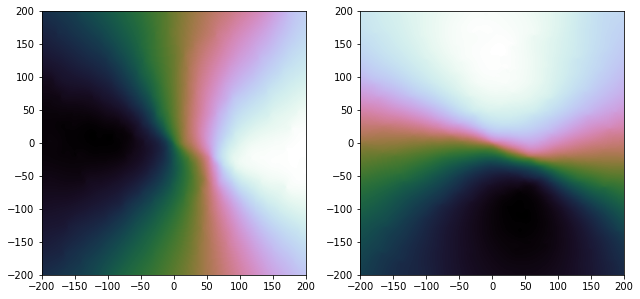

In [99]:
from pyLensLib.raytracer import raytracer
fov_ray=200.0

kwargs = {'zl': cl.zl, 'zs': 3.0, 'fov': fov}
rayt=raytracer(cl.co,'mass_map.fits',Nray=2048,FOVray=fov_ray,fromfile=True,**kwargs)

fig,ax=plt.subplots(1,2,figsize=(9,5))
ax[0].imshow(rayt.a1,cmap="cubehelix",origin='low',extent=[-fov/2.,fov/2.,-fov/2,fov/2])
ax[1].imshow(rayt.a2,origin='low',cmap="cubehelix",extent=[-fov/2.,fov/2.,-fov/2,fov/2])
plt.tight_layout()
plt.show()

# Lensing maps

In [100]:
from pyLensLib.deflector import deflector
kwargs_def={'zl': cl.zl, 'zs': kwargs['zs']}
df_test=deflector(cl.co,angx=rayt.a1,angy=rayt.a2,**kwargs_def)
theta=np.linspace(-fov_ray/2.,fov_ray/2.,2048)
df_test.setGrid(theta=theta,compute_potential=True)

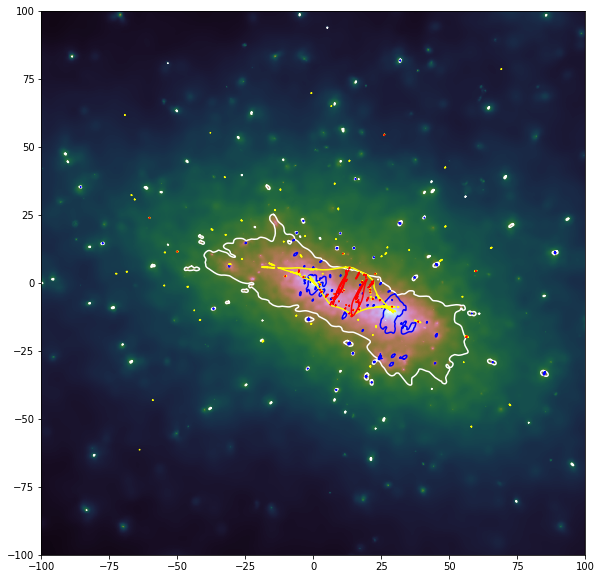

In [101]:
fig,ax=plt.subplots(1,1,figsize=(10,10))
ax.imshow(np.sqrt(df_test.ka),extent=[-100,100,-100,100],origin='low',cmap='cubehelix')
df_test.change_redshift(7.0)
critt=df_test.tancl()
critr=df_test.radcl()
caut=df_test.getCaustics(critt)
caur=df_test.getCaustics(critr)
for c in critt:
    x,y=df_test.getCritPoints(c)
    ax.plot(x,y,'-',color='white') 
for c in critr:
    x,y=df_test.getCritPoints(c)
    ax.plot(x,y,'-',color='blue') 
for c in caut:
    x,y=df_test.getCausticPoints(c)
    ax.plot(x,y,'-',color='yellow') 
for c in caur:
    x,y=df_test.getCausticPoints(c)
    ax.plot(x,y,'-',color='red') 
ax.set_xlim([-100,100])
ax.set_ylim([-100,100])
plt.show()

/Users/massimo/.local/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: divide by zero encountered in log10
  


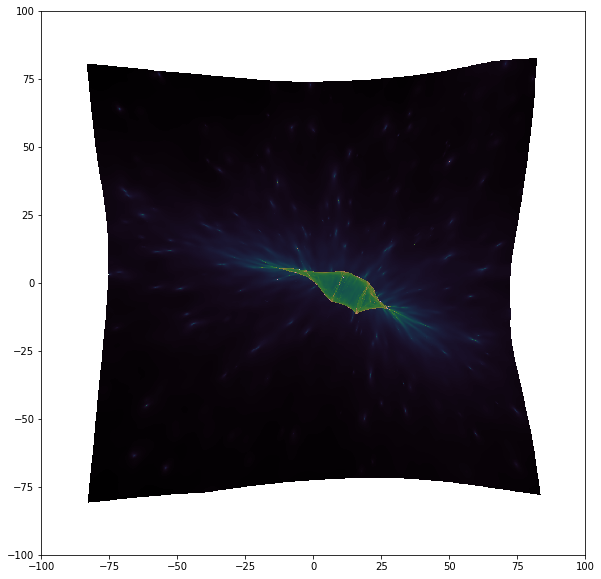

In [122]:
import pymupds
detA = (1.0 - df_test.ka) ** 2 - (df_test.g1 ** 2 + df_test.g2 ** 2)
y1 = df_test.theta1 - df_test.a1 + 2 * df_test.grid_pixel
y2 = df_test.theta2 - df_test.a2 + 2 * df_test.grid_pixel
mus = pymupds.mupds_triangle(y1 - df_test.theta.min(), y2 - df_test.theta2.min(), df_test.grid_pixel, detA, nray=len(theta))

fig,ax=plt.subplots(1,1,figsize=(10,10))
ax.imshow(np.log10(mus.T),extent=[-100,100,-100,100],origin='low',cmap='cubehelix')

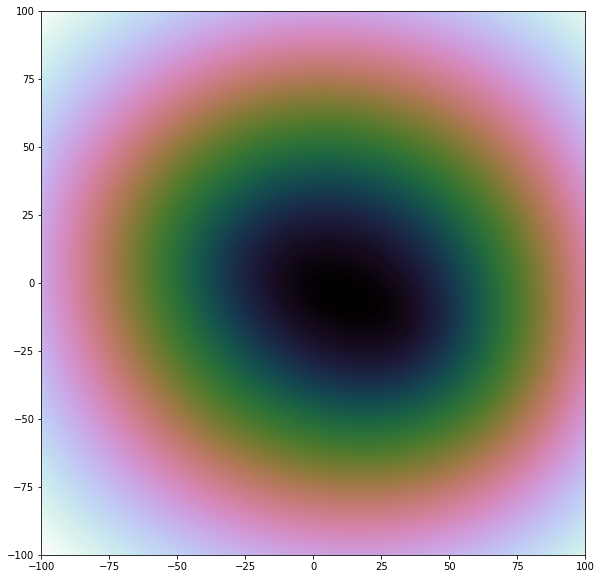

In [102]:
fig,ax=plt.subplots(1,1,figsize=(10,10))
ax.imshow(df_test.pot,extent=[-100,100,-100,100],origin='low',cmap='cubehelix')

# Lens statistics: cross sections for GGSL and multiple images

In [103]:
zsarr=np.logspace(np.log10(0.7),np.log10(7.0),10)
print ("zs        GGSL     mult. images")
for zs_ in zsarr:
    df_test.change_redshift(zs_)
    print ("%3.2f %10.3f %10.3f" % (zs_,df_test.ggslCrossSection(minsize=0.5,maxsize=3.0,dmax=200.0),df_test.multImaCrossSection()))

zs        GGSL     mult. images
0.70      0.000      0.585
0.90      0.064     31.642
1.17      0.508     98.415
1.51      1.269    159.138
1.95      1.986    209.424
2.52      1.792    249.131
3.25      2.010    279.925
4.20      2.671    302.662
5.42      2.337    320.020
7.00      2.845    333.739


# Time delays and image simulations

[39.6515637  33.30082142 10.07981017 28.44809765 23.26980007]
[-12.39211454   5.87851127 -41.05198202  -9.9821354   -7.34413613]
[4.34879367 5.38537645 2.47255365 0.6733397  2.22915984]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
totarea 324.79237811335014 0.09770395701025336 200.09770395699888 95


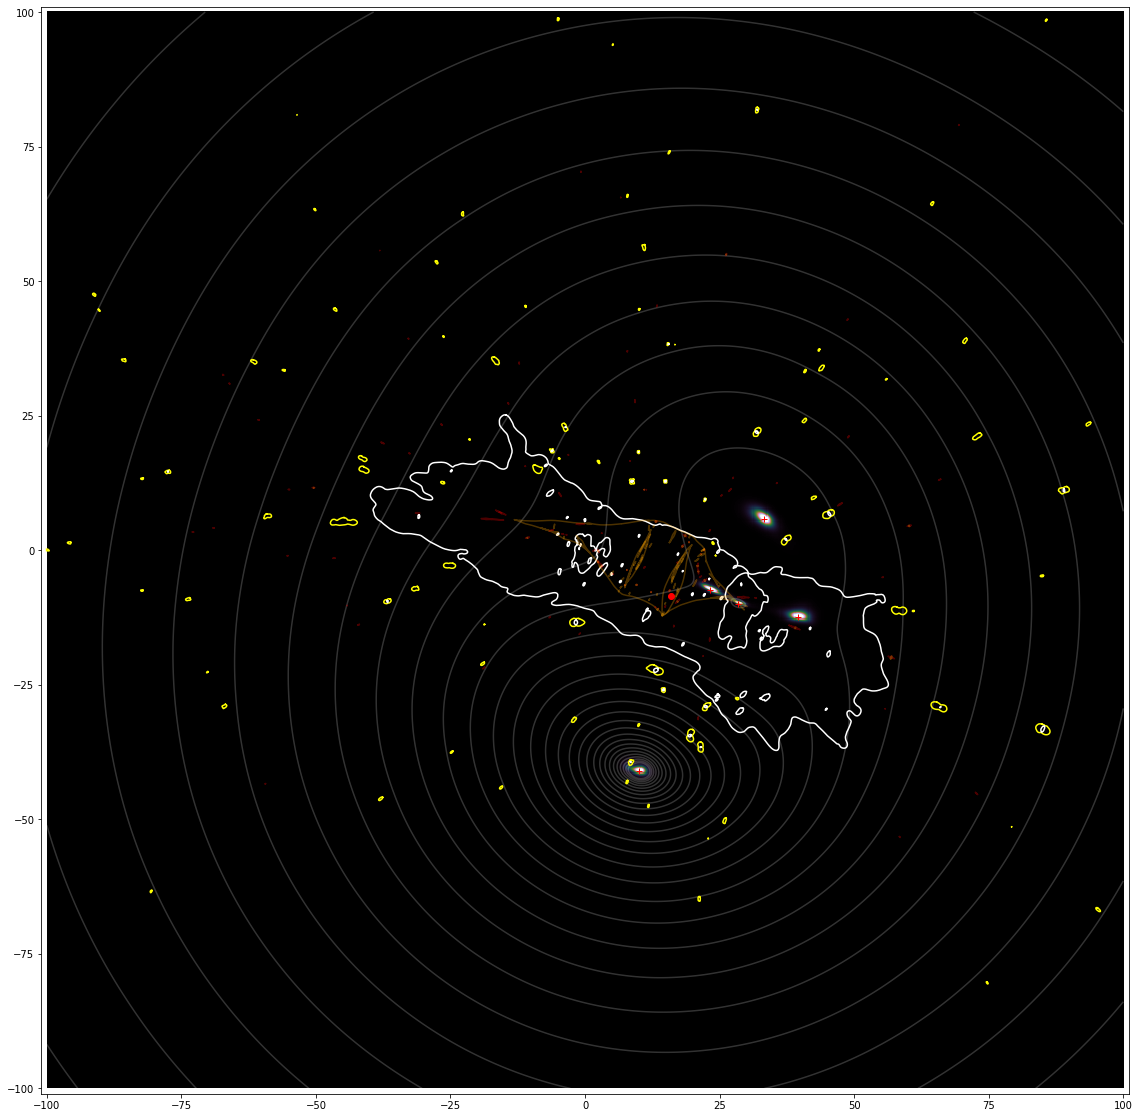

In [109]:
beta=[15.974,-8.57143]
from pyLensLib.pointsrc import pointsrc
from pyLensLib.observation import observation
from pyLensLib.sersic import sersic
df=deflector(cl.co,pot=rayt.pot,usePotential=True,**kwargs_def)
theta=np.linspace(-fov_ray/2.,fov_ray/2.,2048)
df.setGrid(theta=theta,compute_potential=True)

# simulate the observation of a source modeled with a Sersic profile
mag_source=23.0
ob = observation(size=200.0, Npix=1000, zp=23.9, texp=565*4, bkg=22.0)
fl_gal=ob.mag2counts(mag_source)
kwargs_source_light={
    'n': 1.0, # sersic index
    're': 0.5, # effective radius
    'q': 1.0, # axis ratio
    'pa': np.pi/4., # position angle
    'ys1': beta[0], # position x (on the source plane)
    'ys2': beta[1], # position y (on the lens plane)
    'flux': fl_gal, # flux of the source (in counts/s)
    'zs': 5.8
}
df.change_redshift(kwargs_source_light['zs'])
se=sersic(size=200.0, Npix=1000,gl=df,**kwargs_source_light)

# simulate a point source and find its images
kwargs_psr = {
    'zs': kwargs_source_light['zs'],
    'ys1': beta[0],
    'ys2': beta[1]
}

ps=pointsrc(size=200.0, sizex=None, sizey=None, Npix=1000, gl=df, **kwargs_psr)
xi,yi,mui=ps.find_images()

# plot results: image of the extended source, time-delay levels, critical lines, etc.
fig,ax=plt.subplots(1,1,figsize=(20,20))
tds=df.t_delay_surf(beta=beta)
ax.imshow(se.image,origin='low',extent=[-100,100,-100,100],vmax=se.image.max()*0.5,cmap='cubehelix')
ax.contour(np.sqrt((tds-tds.min())/(tds.max()-tds.min())),levels=np.logspace(-2,0,30),
           extent=[theta.min(),theta.max(),theta.min(),theta.max()],colors='white',alpha=0.2)
tl=df.tancl()
rl=df.radcl()
ctl=df.getCaustics(tl)
crl=df.getCaustics(rl)
for c in tl:
    x,y=df.getCritPoints(c,pixel_units=False)
    if (c.principale):
        ax.plot(x,y,'-',color='white')
    else:
        ax.plot(x,y,'-',color='yellow')
for c in rl:
    x,y=df.getCritPoints(c,pixel_units=False)
    ax.plot(x,y,'-',color='white')

totarea=0.0
for c in ctl:
    x,y=df.getCausticPoints(c)
    if (c.principale):
        ax.plot(x,y,'-',color='orange',alpha=0.3)
    else:
        ax.plot(x, y, '-', color='red', alpha=0.3)
    totarea+=c.area*df.grid_pixel**2

print ('totarea', totarea, df.grid_pixel, df.nray*df.pixel_scale, len(ctl))

for c in crl:
    x,y=df.getCausticPoints(c)
    ax.plot(x,y,'-',color='orange',alpha=0.3)
ax.imshow(tds-tds.min(),origin='low',extent=[-fov_ray/2,fov_ray/2,-fov_ray/2,fov_ray/2.0],alpha=0.001,cmap='cubehelix')
ax.plot(beta[0],beta[1],'o',color='red')
ax.plot(xi,yi,'+',color='red')
ax.set_ylim([-101,101])
ax.set_xlim([-101,101])
plt.show()

# Build complex models

[-1.87758348e+01  1.98181169e+01  1.95247231e+01  1.51276437e+01
  1.23914943e+01  1.17076572e+01  1.08616701e+01  1.66297692e-02
  1.98466388e+01  1.15421148e+01 -3.20677951e+00  1.48716422e+00
  6.07959811e-01]
[-6.72444988e+00  3.04481787e+00  4.21759849e+00  1.23323600e+01
  1.56436931e+01  1.62309895e+01 -1.58433122e+01 -1.72300678e-02
  2.03638549e+00  1.63984112e+01  1.92296692e+01  1.96178252e+01
  1.97154439e+01]
[1.49995812e+01 9.60035825e+00 1.53584483e+01 9.10804601e+00
 1.58286324e+01 8.09227109e+00 1.50355374e+01 1.20796494e-04
 1.79880344e+01 2.12426157e+01 7.77290444e+00 1.54256324e+01
 4.21796888e+01]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]
[0.0, 0.0]


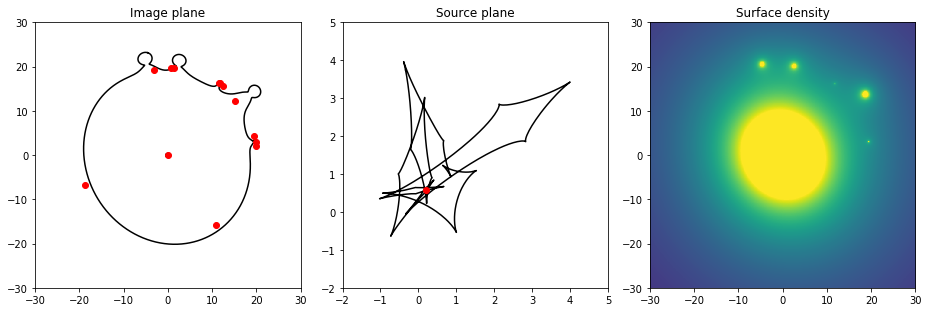

In [124]:
from pyLensLib.piemd import piemd
from astropy.cosmology import FlatLambdaCDM
co = FlatLambdaCDM(H0=70.0, Om0=0.3)
kwargs = {'zl': 0.44,
          'zs': 2.0,
          'sigma0': 1000.0,
          'q': 0.9,
          'pa': np.pi / 6.0,
          'theta_c': 0.01,
          'theta_t': 1000.0,
          'x1': 0.0,
          'x2': 0.0}
lm = piemd(co, **kwargs)
theta=np.linspace(-100.,100.,2048)
lm.setGrid(theta)
cl=lm.tancl()
rl=lm.radcl()

# substructure 1:
kwargs1 = {'zl': 0.44,
          'zs': 2.0,
          'sigma0': 70.0,
          'q': 1.0,
          'pa': np.pi / 8.0,
          'theta_c': 0.0001,
          'theta_t': 60.0,
          'x1': 19.34,
          'x2': 3.0}
lm1 = piemd(co, **kwargs1)
lm1.setGrid(theta)
lm.combinewith(lm1)

# substructure 2:
kwargs1 = {'zl': 0.44,
          'zs': 2.0,
          'sigma0': 200.0,
          'q': 1.0,
          'pa': np.pi / 8.0,
          'theta_c': 0.0001,
          'theta_t': 60.0,
          'x1': 18.6,
          'x2': 13.7}
lm1 = piemd(co, **kwargs1)
lm1.setGrid(theta)
lm.combinewith(lm1)

# substructure 3:
kwargs1 = {'zl': 0.44,
          'zs': 2.0,
          'sigma0': 50.0,
          'q': 1.0,
          'pa': np.pi / 8.0,
          'theta_c': 0.0001,
          'theta_t': 20.0,
          'x1': 11.7,
          'x2': 16.1}
lm1 = piemd(co, **kwargs1)
lm1.setGrid(theta)
lm.combinewith(lm1)

# substructure 4:
kwargs1 = {'zl': 0.44,
          'zs': 2.0,
          'sigma0': 160.0,
          'q': 1.0,
          'pa': np.pi / 8.0,
          'theta_c': 0.0000001,
          'theta_t': 10.0,
          'x1': 2.5,
          'x2': 20.1}
lm1 = piemd(co, **kwargs1)
lm1.setGrid(theta)
lm.combinewith(lm1)

# substructure 5:
kwargs1 = {'zl': 0.44,
          'zs': 2.0,
          'sigma0': 160.0,
          'q': 1.0,
          'pa': np.pi / 8.0,
          'theta_c': 0.0000001,
          'theta_t': 10.0,
          'x1': -4.7,
          'x2': 20.5}
lm1 = piemd(co, **kwargs1)
lm1.setGrid(theta)
lm.combinewith(lm1)

cl=lm.tancl()
rl=lm.radcl()

cacl=lm.getCaustics(cl)
carl=lm.getCaustics(rl)
fig,ax=plt.subplots(1,3,figsize=(13,7))

ax[2].imshow(lm.ka,origin='low',vmax=1,extent=[-100,100,-100,100])
for i in range(len(cl)):
    x,y=lm.getCritPoints(cl[i])
    xc,yc=lm.getCausticPoints(cacl[i])
    ax[0].plot(x,y,'-',color='black')
    ax[1].plot(xc,yc,'-',color='black')
for i in range(len(rl)):
    x,y=lm.getCritPoints(rl[i])
    xc,yc=lm.getCausticPoints(carl[i])
    ax[0].plot(x,y,'-',color='black')
    ax[1].plot(xc,yc,'-',color='black')
    
ax[0].set_xlim([-30,30])
ax[0].set_ylim([-30,30])
ax[2].set_xlim([-30,30])
ax[2].set_ylim([-30,30])
ax[1].set_xlim([-2,5])
ax[1].set_ylim([-2,5])

xxs=-1.0
yys=-0.35


kwargs={
    'ys1': 0.2,#0.13,
    'ys2': 0.57,#0.11,
    'zs': 2
}
ps=pointsrc(size=fov,gl=lm,Npix=1000,**kwargs)
xi,yi,mui=ps.find_images()
ax[1].plot(kwargs['ys1'],kwargs['ys2'],'o',color='red')
ax[0].plot(xi,yi,'o',color='red')

ax[0].set_title('Image plane')
ax[1].set_title('Source plane')
ax[2].set_title('Surface density')

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
plt.tight_layout()